# Unit Sales Forecasting
## RNN, LSTM, and Hyperopt Tuning — built with PyTorch

This notebook applies neural network forecasting to the unit sales dataset.  
It uses **PyTorch** instead of TensorFlow, which installs cleanly on Windows  
with Anaconda and has no conflicts with Streamlit or MLflow.

**Workflow:**
1. Install and import libraries
2. Load and visualize data
3. Preprocess (scale, create sequences)
4. Train / test split
5. Build a Simple RNN baseline
6. Build an LSTM model
7. Tune the LSTM with Hyperopt
8. Compare all models

---
## 1. Install and Import Libraries

In [1]:
# Install all required libraries
! pip install torch hyperopt scikit-learn pandas numpy matplotlib -q

In [2]:
# Import packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

# Hyperopt
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All libraries loaded successfully.")
print("PyTorch version:", torch.__version__)

All libraries loaded successfully.
PyTorch version: 2.2.2+cpu


---
## 2. Load and Visualize Data

In [3]:
# Set the folder where your CSV file is saved
DATA_DIR = 'C:\\Users\\tthem\\timeseries-april\\data'

# Load the feature-engineered dataset
df = pd.read_csv(os.path.join(DATA_DIR, 'timeseries_with_features.csv'))

# Convert date column to datetime and sort chronologically
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Drop rows with NaN values (caused by lag features at the start of the series)
df = df.dropna().reset_index(drop=True)

print("Dataset loaded!")
print("Shape:", df.shape)
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print()
print(df[['date', 'unit_sales']].head())

Dataset loaded!
Shape: (422, 25)
Date range: 2013-02-01 to 2014-03-31

        date  unit_sales
0 2013-02-01       401.0
1 2013-02-02       775.0
2 2013-02-03       855.0
3 2013-02-04       411.0
4 2013-02-05       272.0


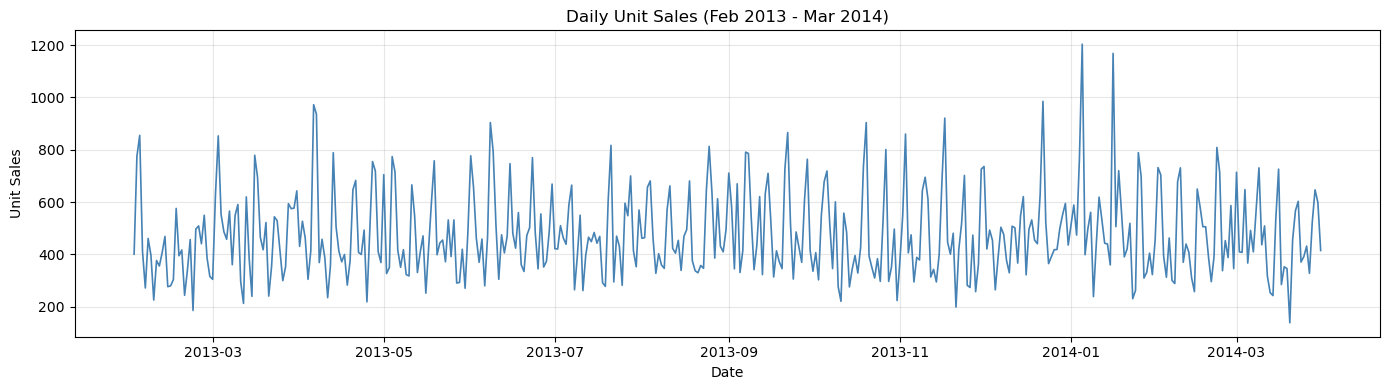

In [4]:
# Plot unit_sales over time
plt.figure(figsize=(14, 4))
plt.plot(df['date'], df['unit_sales'], color='steelblue', linewidth=1.2)
plt.title('Daily Unit Sales (Feb 2013 - Mar 2014)')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Preprocessing

Steps:
- Scale unit_sales to **[0, 1]** using `MinMaxScaler` -- helps the network learn faster
- Convert the series into **supervised sequences**: use the previous `look_back` days  
  as input and the next day as the target

In [5]:
# Scale unit_sales to values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
sales_scaled = scaler.fit_transform(df[['unit_sales']]).flatten()

print("Original range:", df['unit_sales'].min(), "to", df['unit_sales'].max())
print("Scaled range:  ", round(sales_scaled.min(), 2), "to", round(sales_scaled.max(), 2))

Original range: 139.0 to 1203.0
Scaled range:   0.0 to 1.0


In [6]:
# Helper function: create sliding-window sequences
# For each position i, we take the previous look_back values as X
# and the value at position i + look_back as y (the target)

def create_sequences(data, look_back=7):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

# LOOK_BACK = 7 means we use the past 7 days to predict the next day
# This captures the full weekly sales cycle (Mon-Sun pattern)
LOOK_BACK = 7

X, y = create_sequences(sales_scaled, look_back=LOOK_BACK)
print("X shape:", X.shape, "  (samples, time_steps)")
print("y shape:", y.shape)

X shape: (415, 7)   (samples, time_steps)
y shape: (415,)


---
## 4. Train / Test Split

We split at **January 1, 2014** -- everything before is training,  
everything from that date onwards is testing.  
This matches the same split used in all other notebooks in the series.

In [7]:
# Find the row index where January 1, 2014 begins
split_date  = pd.to_datetime('2014-01-01')
split_idx   = df[df['date'] >= split_date].index[0]
split_point = split_idx - LOOK_BACK

# Split into train and test
X_train_np, y_train_np = X[:split_point], y[:split_point]
X_test_np,  y_test_np  = X[split_point:], y[split_point:]

print("Training samples:", len(X_train_np))
print("  Up to:", df['date'].iloc[split_idx - 1].date())
print()
print("Test samples:", len(X_test_np))
print("  From:", df['date'].iloc[split_idx].date())

Training samples: 326
  Up to: 2013-12-31

Test samples: 89
  From: 2014-01-02


In [8]:
# Convert numpy arrays to PyTorch tensors
# PyTorch requires float32 and a feature dimension added to X
# unsqueeze(-1) adds a third dimension: (samples, time_steps) -> (samples, time_steps, 1)

X_train = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(-1)
y_train = torch.tensor(y_train_np, dtype=torch.float32)

X_test  = torch.tensor(X_test_np,  dtype=torch.float32).unsqueeze(-1)
y_test  = torch.tensor(y_test_np,  dtype=torch.float32)

print("X_train tensor shape:", X_train.shape)
print("y_train tensor shape:", y_train.shape)
print("X_test  tensor shape:", X_test.shape)
print("y_test  tensor shape:", y_test.shape)

X_train tensor shape: torch.Size([326, 7, 1])
y_train tensor shape: torch.Size([326])
X_test  tensor shape: torch.Size([89, 7, 1])
y_test  tensor shape: torch.Size([89])


In [9]:
# Wrap training data in a DataLoader
# DataLoader batches the data and shuffles it each epoch during training

BATCH_SIZE = 16

train_dataset = TensorDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoader ready.")
print("Number of batches per epoch:", len(train_loader))

DataLoader ready.
Number of batches per epoch: 21


---
## 5. Evaluation Helper

A function that generates predictions, converts them back to the original  
unit sales scale, and calculates RMSE.

In [10]:
def evaluate_model(model, X_test, y_test, scaler):
    # Switch model to evaluation mode -- turns off dropout and batch norm
    model.eval()

    # torch.no_grad() tells PyTorch not to calculate gradients (saves memory)
    with torch.no_grad():
        y_pred_scaled = model(X_test).squeeze().numpy()

    # Convert predictions and actual values back to original unit sales scale
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = scaler.inverse_transform(y_test.numpy().reshape(-1, 1)).flatten()

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse, y_pred, y_true

print("evaluate_model() function ready.")

evaluate_model() function ready.


---
## 6. Training Helper

A reusable function that trains any model for a given number of epochs  
and tracks the loss each epoch so we can plot it afterwards.

In [11]:
def train_model(model, train_loader, epochs=200, learning_rate=0.001, patience=15):
    # Mean Squared Error loss -- standard for regression problems
    criterion = nn.MSELoss()

    # Adam optimizer -- adjusts learning rate automatically during training
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    best_loss    = float('inf')
    patience_count = 0

    for epoch in range(epochs):
        # Switch to training mode
        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            # Forward pass -- make predictions
            predictions = model(X_batch).squeeze()

            # Calculate loss
            loss = criterion(predictions, y_batch)

            # Backward pass -- calculate gradients
            optimizer.zero_grad()
            loss.backward()

            # Update weights
            optimizer.step()
            epoch_loss += loss.item()

        # Average loss for this epoch
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Early stopping -- stop if loss has not improved for 'patience' epochs
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= patience:
            print("Early stopping at epoch", epoch + 1)
            break

    return train_losses

print("train_model() function ready.")

train_model() function ready.


---
## 7. Model 1 -- Simple RNN (Baseline)

A **Recurrent Neural Network (RNN)** processes sequences step-by-step, passing a hidden state forward at each time step.

**Limitation:** Basic RNNs struggle with long-term dependencies due to vanishing gradients, which is why LSTM was invented.

In [12]:
# Define the Simple RNN model using PyTorch
# nn.Module is the base class for all PyTorch models

class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(SimpleRNN, self).__init__()

        # RNN layer -- processes the sequence step by step
        self.rnn = nn.RNN(
            input_size=input_size,   # 1 feature (unit_sales)
            hidden_size=hidden_size, # 64 neurons in the hidden layer
            batch_first=True         # input shape: (batch, time_steps, features)
        )

        # Output layer -- maps the hidden state to a single prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Run the RNN -- out contains all hidden states, _ is the final hidden state
        out, _ = self.rnn(x)

        # Take only the last time step's output to make the prediction
        out = self.fc(out[:, -1, :])
        return out

# Create and train the RNN model
rnn_model  = SimpleRNN(hidden_size=64)
print("RNN model architecture:")
print(rnn_model)
print()

print("Training Simple RNN...")
rnn_losses = train_model(rnn_model, train_loader, epochs=200, learning_rate=0.001, patience=15)

# Evaluate on the test set
rnn_rmse, rnn_pred, y_true = evaluate_model(rnn_model, X_test, y_test, scaler)
print("Simple RNN  ->  Test RMSE:", round(rnn_rmse, 2), "units")

RNN model architecture:
SimpleRNN(
  (rnn): RNN(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Training Simple RNN...
Simple RNN  ->  Test RMSE: 175.22 units


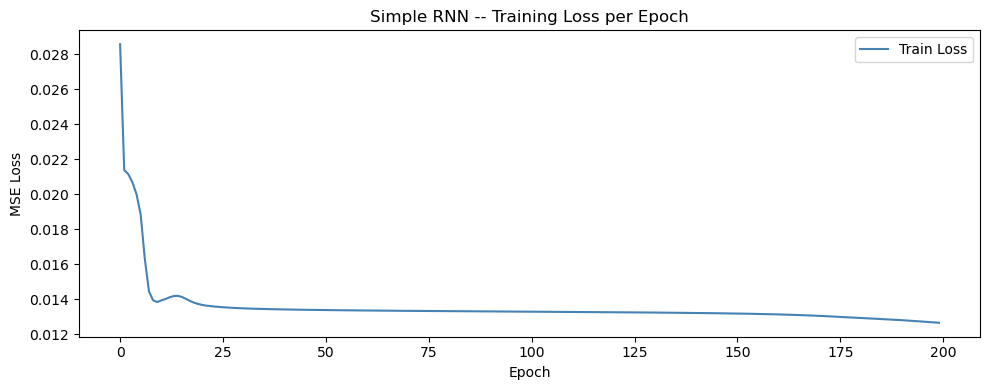

In [13]:
# Plot RNN training loss
plt.figure(figsize=(10, 4))
plt.plot(rnn_losses, color='steelblue', label='Train Loss')
plt.title('Simple RNN -- Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
## 8. Model 2 -- LSTM

**Long Short-Term Memory (LSTM)** extends the RNN with three gates  
(input, forget, output) that control information flow.  
This lets the network selectively remember or forget patterns  
over long sequences -- ideal for daily sales with a weekly cycle.

We use a **two-layer stacked LSTM** for additional capacity.

In [14]:
# Define the Stacked LSTM model

class StackedLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, output_size=1):
        super(StackedLSTM, self).__init__()

        # First LSTM layer -- processes the sequence
        # num_layers=2 stacks two LSTM layers on top of each other
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=2,       # stacked = two layers
            batch_first=True
        )

        # Output layer -- maps hidden state to a single prediction
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Run through stacked LSTM layers
        out, _ = self.lstm(x)

        # Take only the last time step's output
        out = self.fc(out[:, -1, :])
        return out

# Create and train the LSTM model
lstm_model  = StackedLSTM(hidden_size=64)
print("LSTM model architecture:")
print(lstm_model)
print()

print("Training Stacked LSTM...")
lstm_losses = train_model(lstm_model, train_loader, epochs=200, learning_rate=0.001, patience=15)

# Evaluate on the test set
lstm_rmse, lstm_pred, y_true = evaluate_model(lstm_model, X_test, y_test, scaler)
print("Stacked LSTM  ->  Test RMSE:", round(lstm_rmse, 2), "units")

LSTM model architecture:
StackedLSTM(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Training Stacked LSTM...
Stacked LSTM  ->  Test RMSE: 187.73 units


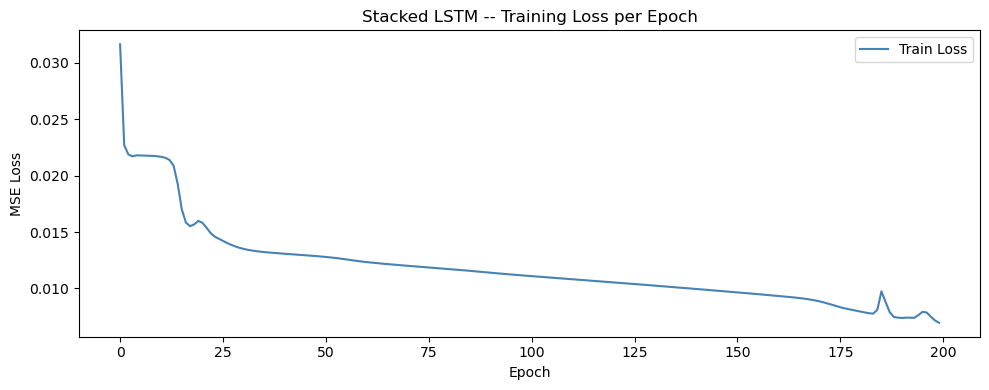

In [15]:
# Plot LSTM training loss
plt.figure(figsize=(10, 4))
plt.plot(lstm_losses, color='steelblue', label='Train Loss')
plt.title('Stacked LSTM -- Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
## 9. Model 3 -- LSTM + Hyperopt Tuning

### What is Hyperopt?
Hyperopt finds the best hyperparameters automatically using **Bayesian optimization**.  
Instead of testing every combination, it learns from each trial and focuses  
on the most promising settings.

### Workflow
1. **Define the search space** -- which hyperparameters and what ranges
2. **Define the objective function** -- builds and trains the model, returns validation loss
3. **Run `fmin()`** -- Hyperopt iterates and returns the best parameters

In [16]:
# STEP 1 -- Define the search space
# hp.choice     -> pick from a list of options
# hp.loguniform -> sample learning rate on a log scale

search_space = {
    'hidden_size':   hp.choice('hidden_size',  [32, 64, 128]),
    'learning_rate': hp.loguniform('lr',       np.log(1e-4), np.log(1e-2)),
    'batch_size':    hp.choice('batch_size',   [8, 16, 32]),
}

print("Search space defined:")
for k in search_space:
    print("  ", k)

Search space defined:
   hidden_size
   learning_rate
   batch_size


In [17]:
# STEP 2 -- Define the objective function
# Hyperopt MINIMIZES the return value so we return the final training loss

def objective(params):
    hidden_size   = params['hidden_size']
    learning_rate = params['learning_rate']
    batch_size    = int(params['batch_size'])

    # Build a fresh LSTM model using this trial's hyperparameters
    model = StackedLSTM(hidden_size=hidden_size)

    # Create a DataLoader with this trial's batch size
    loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    # Train for 100 epochs (shorter for speed during the search)
    losses = train_model(model, loader, epochs=100,
                         learning_rate=learning_rate, patience=10)

    # Return the best loss seen across all epochs
    best_loss = min(losses)
    return {'loss': best_loss, 'status': STATUS_OK, 'params': params}

In [18]:
# STEP 3 -- Run Hyperopt optimization
# max_evals=20 tests 20 different hyperparameter combinations

print("Running Hyperopt -- this may take a few minutes...")
print()

trials = Trials()

best_params = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,                   # Bayesian TPE algorithm
    max_evals=20,
    trials=trials,
    rstate=np.random.default_rng(42)    # Set seed for reproducibility
)

print()
print("Hyperopt complete")
print("Best raw params:", best_params)

Running Hyperopt -- this may take a few minutes...

Early stopping at epoch                                                           
14                                                                                
Early stopping at epoch                                                            
13                                                                                 
Early stopping at epoch                                                            
17                                                                                 
Early stopping at epoch                                                            
15                                                                                 
Early stopping at epoch                                                            
21                                                                                 
Early stopping at epoch                                                            
15                        

In [19]:
# Decode hp.choice indices back to their actual values
hidden_size_choices = [32, 64, 128]
batch_size_choices  = [8, 16, 32]

best_hidden = hidden_size_choices[best_params['hidden_size']]
best_lr     = best_params['lr']
best_batch  = batch_size_choices[best_params['batch_size']]

print("Best hidden size  :", best_hidden)
print("Best learning rate:", round(best_lr, 6))
print("Best batch size   :", best_batch)

Best hidden size  : 64
Best learning rate: 0.003232
Best batch size   : 8


In [20]:
# STEP 4 -- Retrain the final model using the best hyperparameters

print("Training final tuned LSTM...")

tuned_loader = DataLoader(train_dataset, batch_size=best_batch, shuffle=False)

tuned_model  = StackedLSTM(hidden_size=best_hidden)
tuned_losses = train_model(tuned_model, tuned_loader, epochs=200,
                           learning_rate=best_lr, patience=15)

tuned_rmse, tuned_pred, y_true = evaluate_model(tuned_model, X_test, y_test, scaler)
print("Tuned LSTM (Hyperopt)  ->  Test RMSE:", round(tuned_rmse, 2), "units")

Training final tuned LSTM...
Early stopping at epoch 174
Tuned LSTM (Hyperopt)  ->  Test RMSE: 210.55 units


---
## 10. Hyperopt Trial Analysis

This chart shows how the validation loss improved across successive trials.

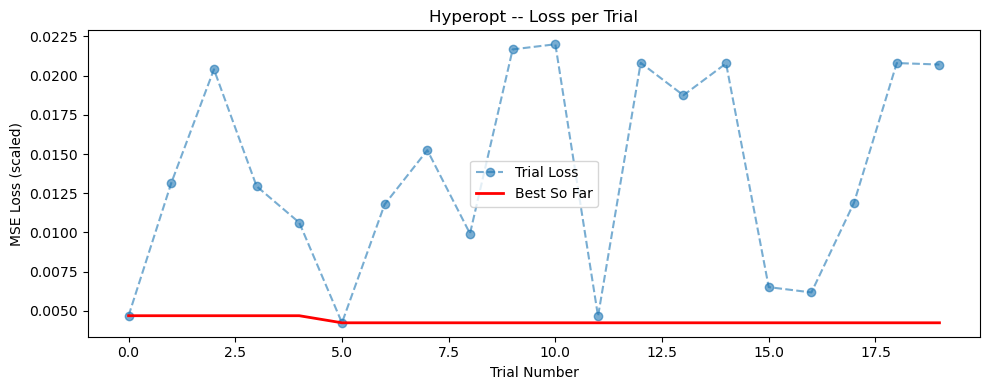

In [21]:
# Extract trial results
trial_losses = [t['result']['loss'] for t in trials.trials]
best_so_far  = np.minimum.accumulate(trial_losses)

plt.figure(figsize=(10, 4))
plt.plot(trial_losses, 'o--', alpha=0.6, label='Trial Loss')
plt.plot(best_so_far,  color='red', linewidth=2, label='Best So Far')
plt.title('Hyperopt -- Loss per Trial')
plt.xlabel('Trial Number')
plt.ylabel('MSE Loss (scaled)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 11. Final Comparison

Compare all three models side-by-side on the same test period (Jan 2014 - Mar 2014).

In [22]:
# Summary table
results = pd.DataFrame({
    'Model':     ['Simple RNN', 'Stacked LSTM', 'Tuned LSTM (Hyperopt)'],
    'Test RMSE': [rnn_rmse,      lstm_rmse,       tuned_rmse]
})
results = results.sort_values('Test RMSE').reset_index(drop=True)
print("Model Comparison -- Test RMSE (lower is better):")
print()
print(results.to_string(index=False))

Model Comparison -- Test RMSE (lower is better):

                Model  Test RMSE
           Simple RNN 175.216934
         Stacked LSTM 187.728439
Tuned LSTM (Hyperopt) 210.546738


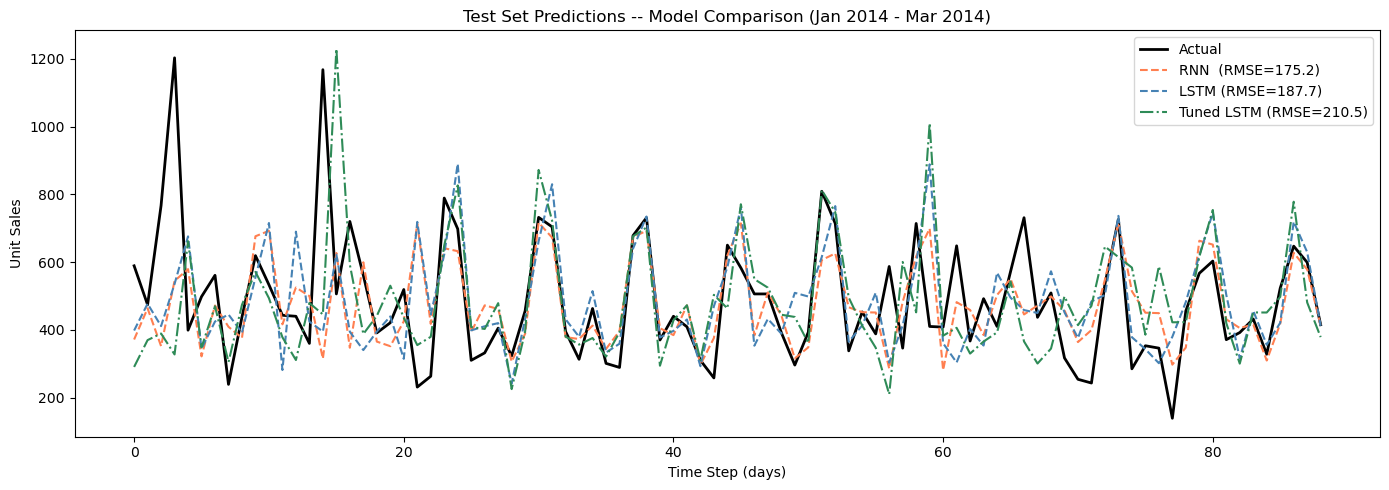

In [23]:
# Visual comparison -- actual vs all three model predictions
plt.figure(figsize=(14, 5))
plt.plot(y_true,     label='Actual',                                              color='black',    linewidth=2)
plt.plot(rnn_pred,   label='RNN  (RMSE=' + str(round(rnn_rmse, 1)) + ')',         linestyle='--',   color='coral')
plt.plot(lstm_pred,  label='LSTM (RMSE=' + str(round(lstm_rmse, 1)) + ')',        linestyle='--',   color='steelblue')
plt.plot(tuned_pred, label='Tuned LSTM (RMSE=' + str(round(tuned_rmse, 1)) + ')', linestyle='-.',   color='seagreen')
plt.title('Test Set Predictions -- Model Comparison (Jan 2014 - Mar 2014)')
plt.xlabel('Time Step (days)')
plt.ylabel('Unit Sales')
plt.legend()
plt.tight_layout()
plt.show()

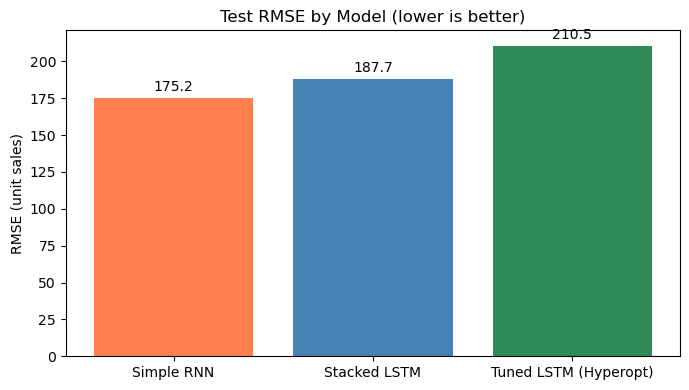

In [24]:
# Bar chart of RMSE scores
colors = ['coral', 'steelblue', 'seagreen']
plt.figure(figsize=(7, 4))
bars = plt.bar(results['Model'], results['Test RMSE'], color=colors[:len(results)])
plt.bar_label(bars, fmt='%.1f', padding=3)
plt.title('Test RMSE by Model (lower is better)')
plt.ylabel('RMSE (unit sales)')
plt.tight_layout()
plt.show()